In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

from bayspecdec.spectrum_gen import *
import bayspecdec as bsd

from functools import partial

In [2]:
import jupyter_black

jupyter_black.load()

In [3]:
Array = np.ndarray[tuple[int], np.dtype(np.float32)]

In [4]:
BIN_SIZE: float = 1e-1
MIN: float = 0
MAX: float = 12

In [5]:
DET_AX: Array = np.arange(MIN, MAX, BIN_SIZE)
PEAK: Array = np.zeros_like(DET_AX)
PEAK += lorentzian(DET_AX, 6, 0.5, 1)

In [6]:
SIGNAL: Array = np.zeros_like(DET_AX)
SIGNAL[bin_idx(DET_AX, 3)] += 1
SIGNAL[bin_idx(DET_AX, 6)] += 2
SIGNAL[bin_idx(DET_AX, 10)] += 2
# SIGNAL[bin_idx(DET_AX, 6)] += 2

BLURRED: Array = sp.signal.convolve(SIGNAL, PEAK, mode="full")[
    len(DET_AX) // 2 : -len(DET_AX) // 2 + 1
]

y = draw_spectrum(BLURRED, dose=1_000_000).astype(np.float64)
y /= y.max()

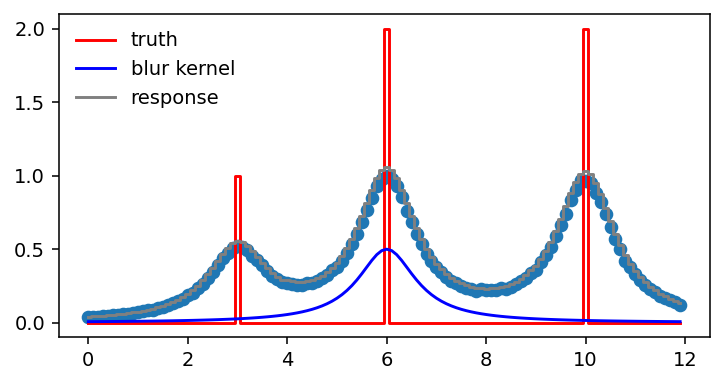

In [7]:
plt.step(DET_AX, SIGNAL, where="mid", label="truth", color="red")
plt.plot(DET_AX, PEAK, label="blur kernel", color="blue")
plt.step(DET_AX, BLURRED, where="mid", label="response", color="gray")
plt.scatter(DET_AX, y)
fig = plt.gcf()
fig.set_size_inches(6, 3)
fig.set_dpi(140)
plt.legend(frameon=False)

In [8]:
from typing import Iterable


class BlurKernel:
    name: str = "BlurKernel"
    n_parameters_per_basis: int = 1

    def evaluate(self, x: Array, params: Iterable[Array]) -> Array:
        (μ,) = params
        evals = []
        for μi in μ:
            peak = lorentzian(x, μi, 0.5, 1)
            peak /= peak.max()
            evals.append(peak)
        return np.stack(evals)

In [9]:
from numba.experimental.jitclass.decorators import jitclass


class Parameterization:
    def __init__(self, K: int):
        self.K = K
        self.ndim = 2 * K

    def pack(self, structured: tuple[Array, Array, Array]) -> Array:
        I, μ = structured
        θ = np.empty(self.ndim)
        θ[: self.K] = I
        θ[self.K : 2 * self.K] = μ
        # θ[2 * self.K :] = σ
        return θ

    def unpack(self, θ: Array) -> tuple[Array, Array, Array]:
        I: Array = θ[..., : self.K]
        μ: Array = θ[..., self.K : 2 * self.K]
        # σ: Array = θ[..., 2 * self.K :]
        return (I, μ)  # , σ)

    def to_z(self, θ: Array) -> Array:
        z = θ.copy()
        # z[..., : self.K] = np.log(z[..., : self.K])
        return z

    def from_z(self, z: Array) -> Array:
        θ = z.copy()
        # θ[..., : self.K] = np.exp(θ[..., : self.K])
        return θ

    def log_jacobian(self, θ: Array) -> float:
        return 1
        I, μ, σ = self.unpack(θ)
        return float(np.sum(np.log(I)) + np.sum(np.log(θ)))

In [10]:
class LorentzPrior:
    def __init__(self, amplitudes, centers):  # , widths):
        self.amplitudes = amplitudes
        self.centers = centers
        # self.widths = widths

    def sample(self, rng, parameterization) -> Array:
        K: int = parameterization.K
        I: Array = self.amplitudes.sample(rng, K)
        μ: Array = self.centers.sample(rng, K)
        # σ: Array = self.widths.sample(rng, K)
        # print(f"I: {I}, μ: {μ}, σ: {σ}")
        # for Ii, μi, σi in zip(I, μ, σ):
        #     plt.plot(lorentzian(DET_AX, μi, σi, Ii))
        # plt.show()
        return parameterization.pack((I, μ))

    def log_prob(self, θ, parameterization) -> float:
        I, μ = parameterization.unpack(θ)
        lp_I = np.sum(self.amplitudes.log_prob(I))
        lp_μ = np.sum(self.centers.log_prob(μ))
        # lp_σ = np.sum(self.widths.log_prob(σ))
        return float(lp_I + lp_μ)  # + lp_σ)

In [31]:
# plt.hist(
#     bsd.GammaPrior(1, 4).sample(np.random.default_rng(), 50_000),
#     range=(0, 10),
#     bins=100,
# );
betas = np.concat([np.arange(0, 1, 0.01), np.array([1.0])])
print(betas)

[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99 1.  ]


In [32]:
lorentz_prior = LorentzPrior(
    amplitudes=bsd.GammaPrior(1, 4),
    centers=bsd.UniformPrior(1, 11),
    # widths=bsd.GammaPrior(5, 8),
)

In [58]:
betas = bsd.beta_schedule(96)

In [59]:
def spectral_model_builder(K: int) -> bsd.SpectralModel:
    return bsd.SpectralModel(
        x=DET_AX,
        y=y,
        basis=BlurKernel(),
        prior=lorentz_prior,
        likelihood=bsd.GaussianNoise(sigma2=0.01),
        parameterization=Parameterization(K=K),
    )


def sampler_builder(model, rng):
    K = model.parameterization.K
    return bsd.ParallelTempering(
        model=model,
        betas=betas,
        rng=np.random.default_rng(),
        kernel_factory=lambda model, beta, rng: bsd.hmc_kernel_factory(
            model, beta, rng
        ),
    )

In [60]:
runs = bsd.select_model_size(
    model_factory=spectral_model_builder,
    K_values=[2, 3, 4],
    sampler_factory=sampler_builder,
    burn_in=1_00,
    samples=1_00,
    swap_every=1,
    # store_state_trace=True,
)

100%|███████████████████████████████████████████████████████████████████| 100/100 [00:35<00:00,  2.85it/s]


 0 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 1 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 2 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 3 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 4 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 5 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 6 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 7 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 8 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 9 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
10 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
11 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
12 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
13 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=10

100%|███████████████████████████████████████████████████████████████████| 100/100 [00:52<00:00,  1.90it/s]


 0 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 1 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 2 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 3 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 4 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 5 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 6 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 7 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 8 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 9 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
10 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
11 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
12 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
13 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=10

100%|███████████████████████████████████████████████████████████████████| 100/100 [01:15<00:00,  1.33it/s]

 0 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 1 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 2 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 3 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 4 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 5 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 6 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 7 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 8 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
 9 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
10 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
11 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
12 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=100.0/100
13 beta=0.0000->0.0000 Δβ=0.0000 log-ratio=-0.0000 weight-ESS=10

In [61]:
evidence = [r.evidence.log_z for r in runs]
best_run = np.argmin(evidence)
K_values = [r.K for r in runs]

optimal_K = K_values[best_run]
print(f"K: {optimal_K}, -logZ: {evidence[best_run]}")

K: 2, -logZ: -181.0483630490879


In [62]:
print(evidence)

[-181.0483630490879, -28.690736100710364, -27.720053798286553]


In [63]:
posteriors = runs[best_run].exchange_result.samples_by_temperature[-1]

μ: 5.946±0.020;
μ: 9.998±0.027;


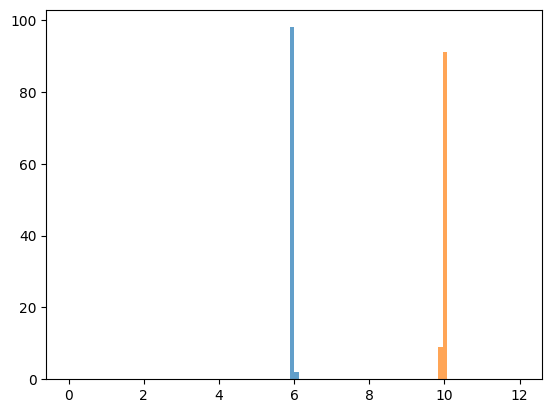

In [64]:
I, μ = Parameterization(K=optimal_K).unpack(
    runs[best_run].exchange_result.samples_by_temperature[-1]
)
key = np.argsort(μ, axis=1)

I = np.take_along_axis(I, axis=1, indices=key)
μ = np.take_along_axis(μ, axis=1, indices=key)
# σ = np.take_along_axis(σ, axis=1, indices=key)

for i in range(optimal_K):
    plt.hist(μ[:, i], range=(0, 12), bins=100, alpha=0.7)
    print(
        f"μ: {np.nanmean(μ[:, i]):.3f}±{np.nanstd(μ[:, i]):.3f};"  # σ: {np.nanmean(σ[:, i]):.3f}±{np.nanstd(σ[:, i]):.2f}"
    )

center: 5.95, height: 1.03
center: 10.00, height: 0.94


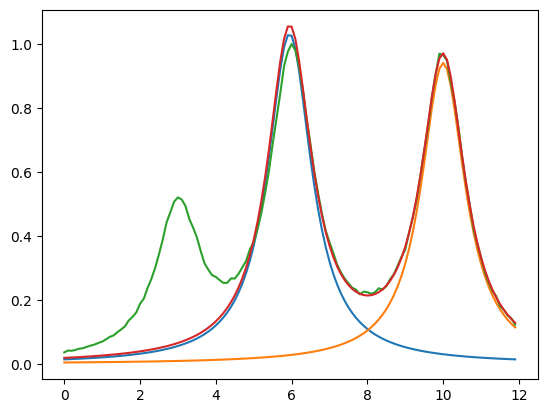

In [65]:
evals = []
for i in range(optimal_K):
    Ii = np.nanmean(I[:, i])
    μi = np.nanmean(μ[:, i])
    # σi = np.nanmean(σ[:, i])
    print(f"center: {μi:.2f}, height: {Ii:.2f}")
    trace = lorentzian(DET_AX, μi, 0.5, 1)
    trace /= trace.max()
    trace *= Ii
    evals.append(trace)
    plt.plot(DET_AX, trace)

plt.plot(DET_AX, y)
plt.plot(DET_AX, np.stack(evals).sum(axis=0))

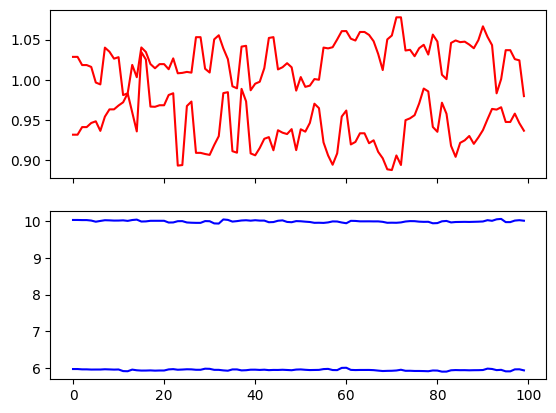

In [66]:
result = runs[best_run].exchange_result
states = result.samples_by_temperature[-1]
I, μ = Parameterization(K=optimal_K).unpack(states)
key = np.argsort(μ, axis=1)

I = np.take_along_axis(I, indices=key, axis=1)
μ = np.take_along_axis(μ, indices=key, axis=1)
# σ = np.take_along_axis(σ, indices=key, axis=1)

fig, (tax, bax) = plt.subplots(nrows=2, sharex=True)

tax.plot(
    I,
    label="amplitudes",
    color="red",
)
bax.plot(
    μ,
    label="centers",
    color="blue",
)

In [51]:
samples = result.samples_by_temperature[-1]

recomputed = np.array(
    [spectral_model_builder(optimal_K).log_likelihood(theta) for theta in samples]
)
stored = np.asarray(result.log_likelihood_trace_by_temperature[-1])

difference = np.max(np.abs(stored - recomputed))
print(difference)

0.0


Text(0, 0.5, '$\\log Z(\\beta_{l+1})/Z(\\beta_l)$')

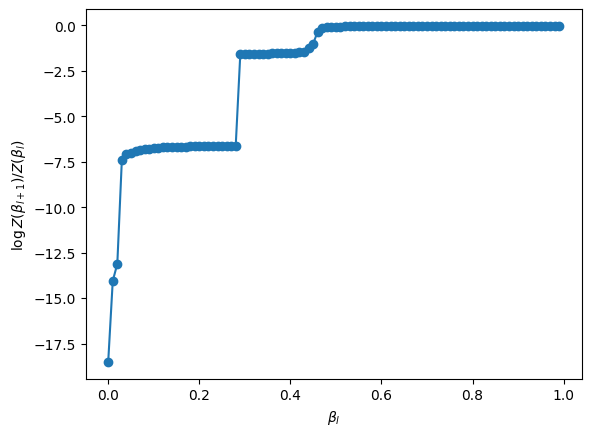

In [52]:
plt.plot(
    result.beta[:-1],
    runs[best_run].evidence.log_ratios,
    marker="o",
)

plt.xlabel(r"$\beta_l$")
plt.ylabel(r"$\log Z(\beta_{l+1})/Z(\beta_l)$")

In [44]:
for l_index in range(result.beta.size - 1):
    delta_beta = result.beta[l_index + 1] - result.beta[l_index]

    log_likelihoods = np.asarray(
        result.log_likelihood_trace_by_temperature[l_index],
        dtype=float,
    )

    log_weights = delta_beta * log_likelihoods

    print(
        f"l: {l_index}, min: {np.min(log_weights):.2f}, max: {np.max(log_weights):.2f}, std: {np.std(log_weights):.2f}"
    )

l: 0, min: -19.74, max: -15.28, std: 0.82
l: 1, min: -19.26, max: -13.94, std: 0.90
l: 2, min: -16.34, max: -7.23, std: 3.03
l: 3, min: -13.72, max: -6.57, std: 1.05
l: 4, min: -8.04, max: -3.81, std: 0.53
l: 5, min: -8.34, max: -2.39, std: 0.61
l: 6, min: -7.96, max: -1.98, std: 0.55
l: 7, min: -7.42, max: -1.81, std: 0.54
l: 8, min: -7.50, max: -6.55, std: 0.18
l: 9, min: -7.42, max: -6.49, std: 0.15
l: 10, min: -7.48, max: -6.55, std: 0.16
l: 11, min: -7.17, max: -6.46, std: 0.11
l: 12, min: -7.17, max: -6.44, std: 0.11
l: 13, min: -7.08, max: -6.41, std: 0.11
l: 14, min: -6.94, max: -6.41, std: 0.09
l: 15, min: -6.86, max: -6.44, std: 0.08
l: 16, min: -6.90, max: -6.45, std: 0.08
l: 17, min: -6.97, max: -6.45, std: 0.10
l: 18, min: -6.93, max: -6.49, std: 0.09
l: 19, min: -6.90, max: -6.43, std: 0.09
l: 20, min: -6.89, max: -6.54, std: 0.08
l: 21, min: -6.98, max: -6.42, std: 0.08
l: 22, min: -6.84, max: -6.42, std: 0.07
l: 23, min: -6.87, max: -6.41, std: 0.07
l: 24, min: -6.85, m

Text(0, 0.5, '$E_\\beta[\\log L]$')

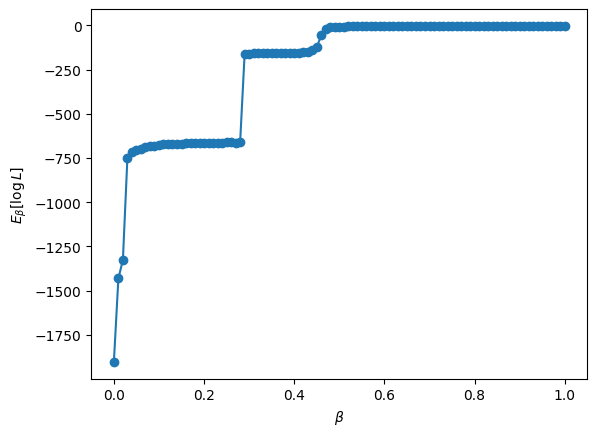

In [55]:
mean_log_likelihood = np.array(
    [np.mean(trace) for trace in result.log_likelihood_trace_by_temperature]
)

plt.plot(result.beta, mean_log_likelihood, marker="o")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$E_\beta[\log L]$")

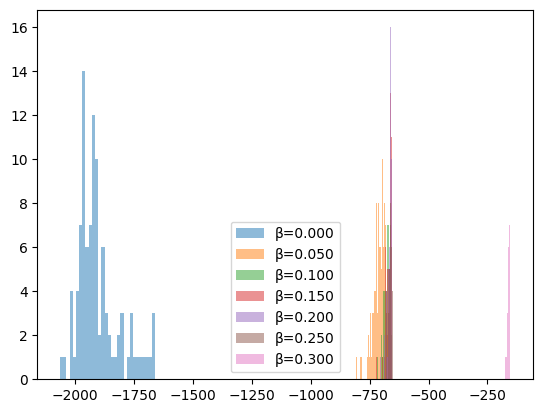

In [56]:
indices = [0, 5, 10, 15, 20, 25, 30]
for i in indices:
    plt.hist(
        result.log_likelihood_trace_by_temperature[i],
        bins=30,
        alpha=0.5,
        label=f"β={result.beta[i]:.3f}",
    )

plt.legend()

Text(0, 0.5, '$\\mathrm{Var}_\\beta(\\log L)$')

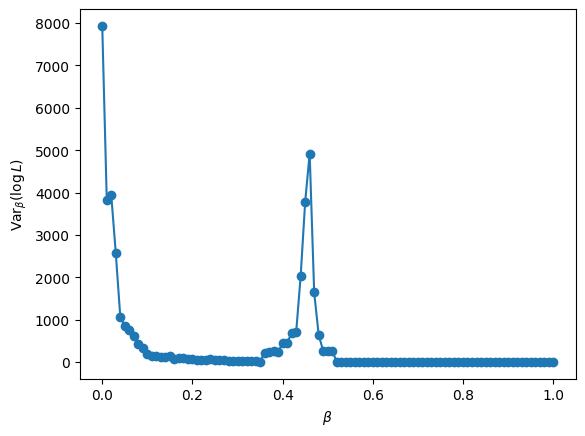

In [57]:
logL_var = np.array(
    [np.var(trace) for trace in result.log_likelihood_trace_by_temperature]
)

plt.plot(result.beta, logL_var, marker="o")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\mathrm{Var}_\beta(\log L)$")